<a href="https://colab.research.google.com/github/pavan09876519/Seasonal-Agricultural-Performance-Data-Analytics/blob/main/Seasonal_Agricultural_Performance_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns',None)

pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [103]:

FilePath = "/content/seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(FilePath)
print("dataset loadesd sucessfully")

dataset loadesd sucessfully


In [104]:
print("number of rows:",df.shape[0])
print("number of columns:",df.shape[1])

number of rows: 4000
number of columns: 28


In [105]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [106]:
df.tail()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [107]:
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.70,26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [108]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [110]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


In [111]:
df.describe(include='object')

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


In [112]:
missing=df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean()*100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage.round(2)
    })
missing_summary[missing_summary["missing_count"]>0]


,missing_count,missing_percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


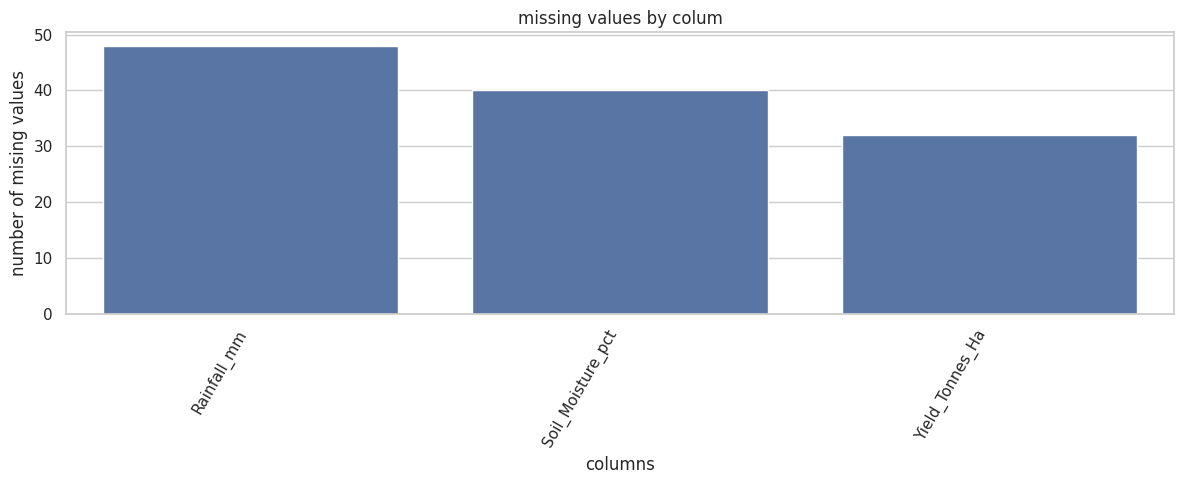

In [113]:
plt.figure(figsize=(12,5))
missing_plot =  missing[missing>0]
if len(missing_plot)>0:
  sns.barplot(x=missing_plot.index,y=missing_plot.values)
  plt.xticks(rotation=60,ha="right")
  plt.ylabel("number of mising values")
  plt.xlabel("columns")
  plt.title("missing values by colum")
  plt.tight_layout()
  plt.show()
else:
  print("no missing values found.")

In [114]:
duplicat_count=df.duplicated().sum()
print("number of duplicated rows:",duplicat_count)

number of duplicated rows: 0


In [115]:
df=df.drop_duplicates().reset_index(drop=True)
print("shape afteer rowing duplicates:",df.shape)

shape afteer rowing duplicates: (4000, 28)


In [116]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [117]:
categorical_columns = df.select_dtypes(include="object").columns
for col in categorical_columns:
  print(f"\n{col}:")
  print(df[col].nunique(),"unique values")
  print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [118]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


In [119]:
numeric_columns = df.select_dtypes(include=np.number).columns
for col  in numeric_columns:
  if df[col].isnull().sum()>0:
    df[col]=df[col].fillna(df[col].median())
print("remaining missing valuees:",df.isnull().sum().sum())

remaining missing valuees: 0


In [120]:
numeric_columns=df.select_dtypes(include=np.number).columns.tolist()
categorical_columns=df.select_dtypes(include="object").columns.tolist()
print("numerical columns:")
print(numeric_columns)
print("\ncategorical columns:")
print(categorical_columns)

numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [121]:
stats = df[numeric_columns].describe().T
stats["range"]=stats["max"]-stats["min"]
stats['IQR']=stats["75%"]-stats["25%"]
stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,4000.00,600.92,287.19,80.00,371.58,582.00,831.98,1395.20,1315.20,460.40
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,4000.00,26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [122]:
statistical_summary = pd.DataFrame({
    "mean": df[numeric_columns].mean(),
    "median": df[numeric_columns].median(),
    "std_dev": df[numeric_columns].std(),
    "min": df[numeric_columns].min(),
    "max": df[numeric_columns].max(),

})
statistical_summary

,mean,median,std_dev,min,max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,1395.20
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [123]:
season_summary =df.groupby("Season")[numeric_columns].agg(["mean","median","std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                   Total_Cost_INR            \
                         mean   median      std           mean    median   
Season                                                                     
Kharif               44850.91 25793.00 30301.56      531804.41 524840.00   
Rabi                 44747.97 26041.00 30309.56      513836.58 506733.00   
Zaid                 44212.03 25749.50 30086.23      543976.73 534833.00   

                 Revenue_INR                     Profit_INR            \
             std        mean    median       std       mean    median   
Season                                                                  
Kharif 298487.69   710719.06 520196.00 708710.37  178914.65  38808.00   
Rabi   288386.89   601526.05 438156.00 584545.52   87689.47  -3187.00   
Zaid   297576.86   519171.90 373700.50 509524.55  -24804.82 -62144.00   

                 Water_Used_m3                 Water_Efficiency_t_per_1000m3  \
      

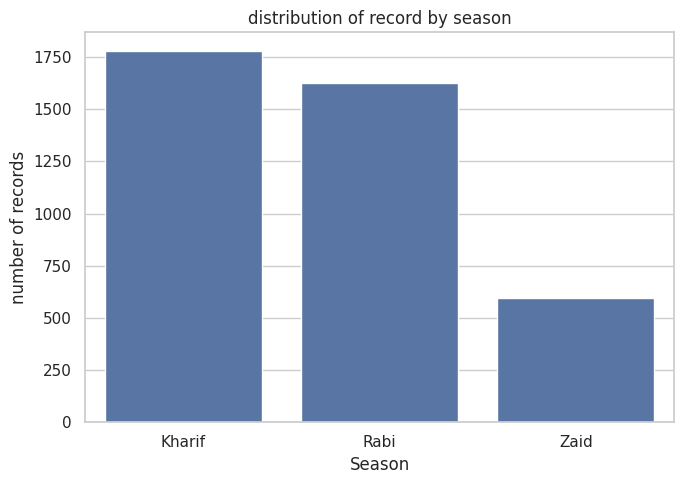

In [124]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="Season")
plt.title("distribution of record by season")
plt.xlabel("Season")
plt.ylabel("number of records")
plt.tight_layout()
plt.show()

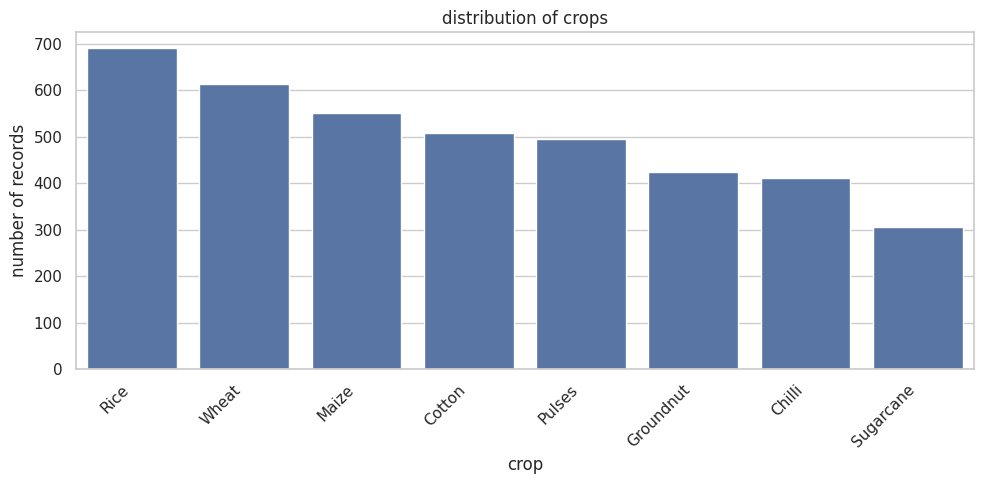

In [125]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="Crop",order=df["Crop"].value_counts().index)
plt.xticks(rotation=45,ha="right")
plt.title("distribution of crops")
plt.xlabel("crop")
plt.ylabel("number of records")
plt.tight_layout()
plt.show()

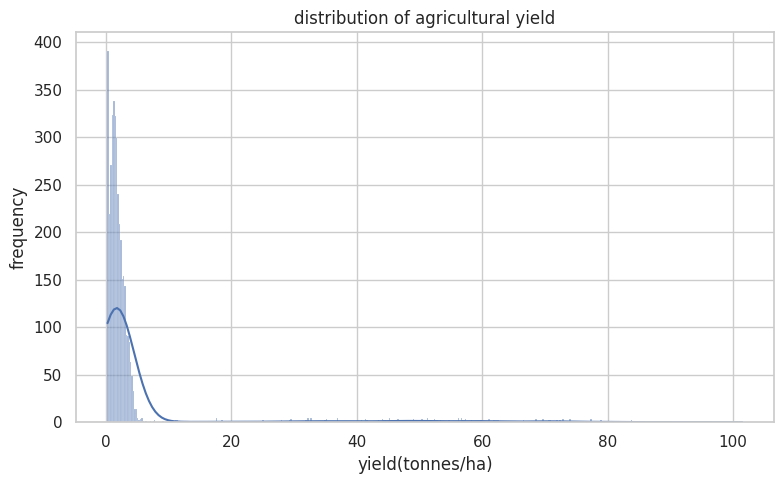

In [126]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Yield_Tonnes_Ha", kde=True)
plt.title("distribution of agricultural yield")
plt.xlabel("yield(tonnes/ha)")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()

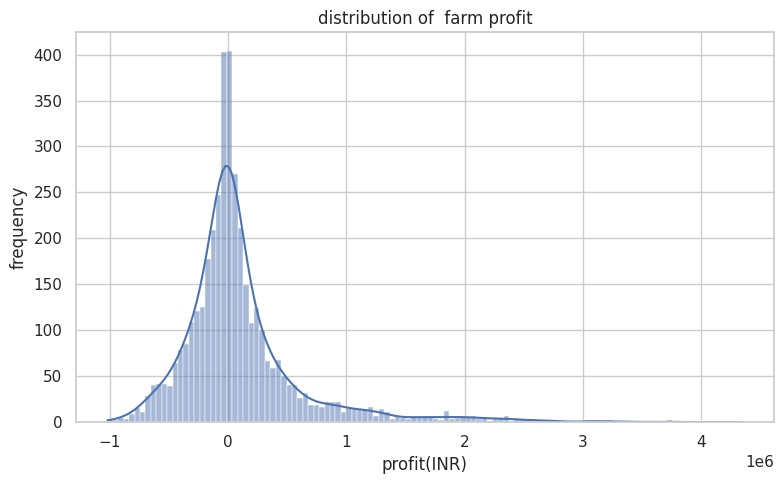

In [127]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Profit_INR", kde=True)
plt.title("distribution of  farm profit")
plt.xlabel("profit(INR)")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()

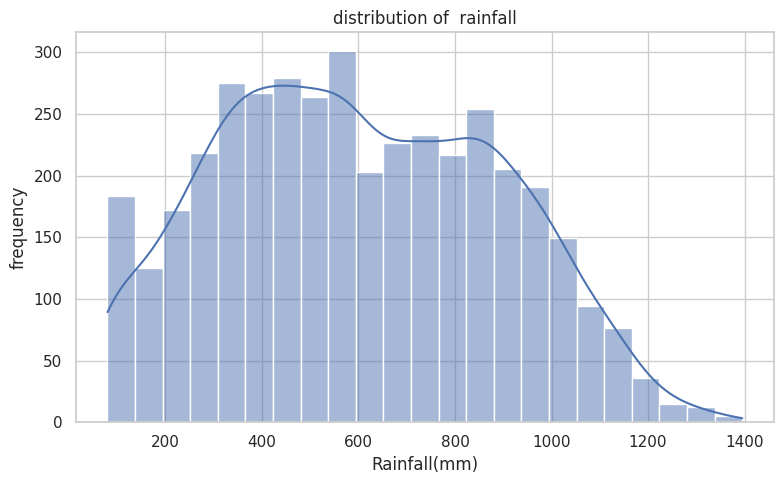

In [128]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Rainfall_mm", kde=True)
plt.title("distribution of  rainfall")
plt.xlabel("Rainfall(mm)")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()

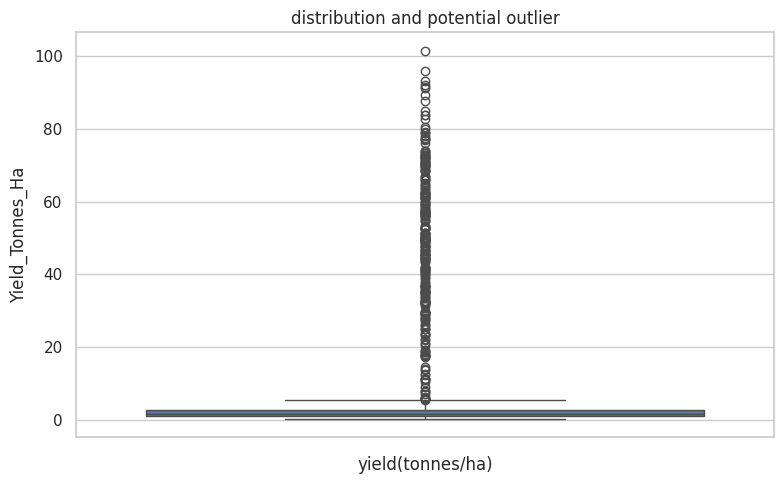

In [129]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,y="Yield_Tonnes_Ha")
plt.title("distribution and potential outlier")
plt.xlabel("yield(tonnes/ha)")
plt.tight_layout()
plt.show()

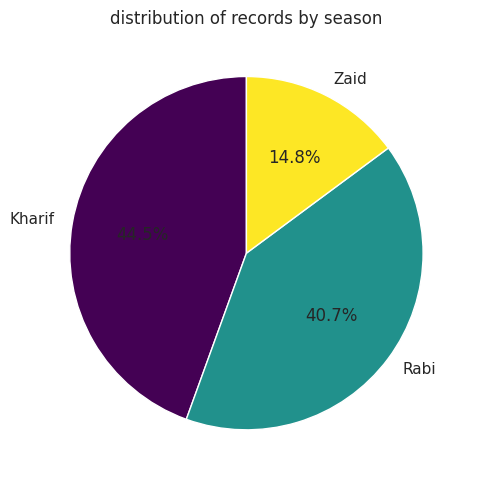

In [130]:
plt.figure(figsize=(8,5))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%',startangle=90,cmap='viridis')
plt.title("distribution of records by season")
plt.ylabel('')
plt.tight_layout()
plt.show()

In [131]:
outlier_Summary = []
for col in numeric_columns:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  lower=q1-1.5*iqr
  upper=q3+1.5*iqr
  count = ((df[col]< lower )|(df[col] > upper)).sum()


  outlier_Summary.append({
      "column":col,
      "lower_bound":lower,
      "upper_bound":upper,
      "outlier_count":count,
      "outlier_percentage":round(count/len(df)*100,2)
  })
outlier_summary_df=pd.DataFrame(outlier_Summary).sort_values("outlier_count",ascending=False)
outlier_summary_df

,column,lower_bound,upper_bound,outlier_count,outlier_percentage
18,Profit_INR,-696111.00,763567.00,404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,-6072.75,16171.25,276,6.90
17,Revenue_INR,-736519.00,1780911.00,240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


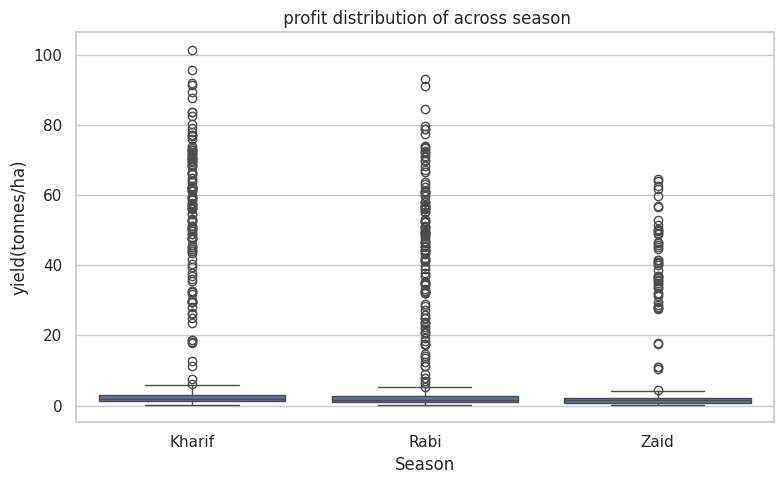

In [132]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Yield_Tonnes_Ha")
plt.title(" profit distribution of across season")
plt.xlabel("Season")
plt.ylabel("yield(tonnes/ha)")
plt.tight_layout()
plt.show()

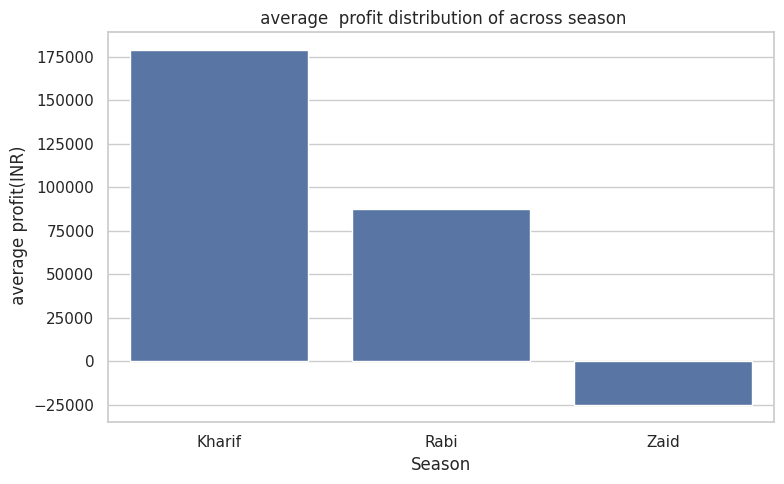

In [133]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Profit_INR",errorbar=None)
plt.title(" average  profit distribution of across season")
plt.xlabel("Season")
plt.ylabel(" average profit(INR)")
plt.tight_layout()
plt.show()

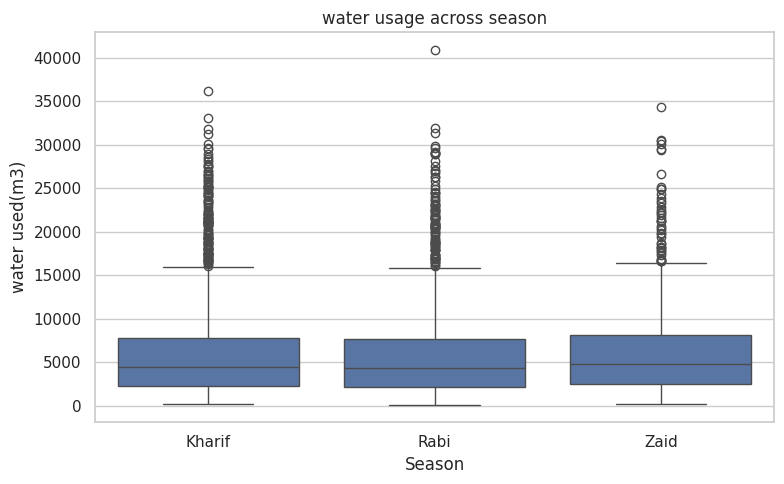

In [134]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Water_Used_m3")
plt.title("water usage across season")
plt.xlabel("Season")
plt.ylabel("water used(m3)")
plt.tight_layout()
plt.show()


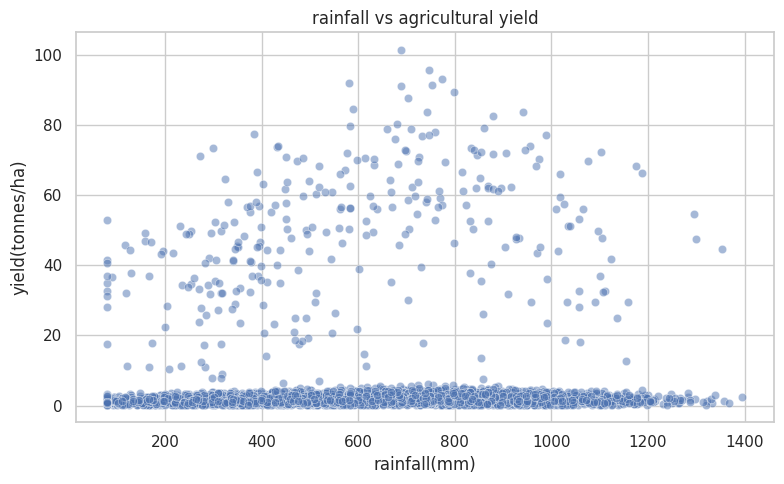

In [135]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Rainfall_mm",y="Yield_Tonnes_Ha",alpha=0.5)
plt.title("rainfall vs agricultural yield")
plt.xlabel("rainfall(mm)")
plt.ylabel("yield(tonnes/ha)")
plt.tight_layout()
plt.show()

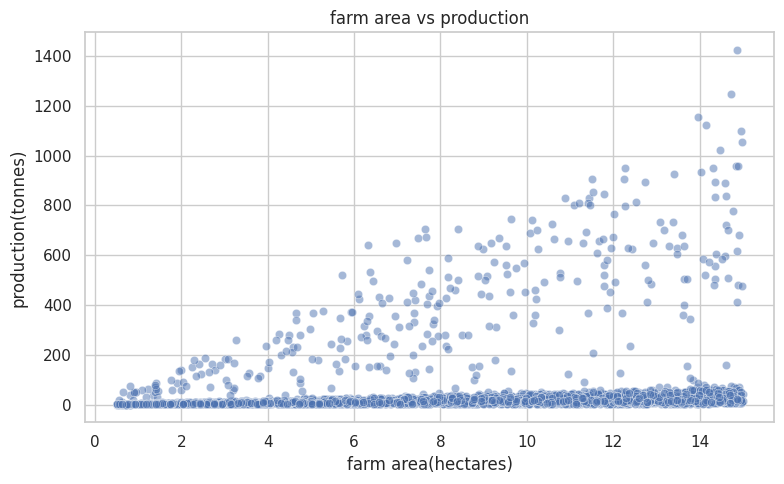

In [136]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Farm_Area_Hectares",y="Production_Tonnes",alpha=0.5)
plt.title("farm area vs production")
plt.xlabel("farm area(hectares)")
plt.ylabel("production(tonnes)")
plt.tight_layout()
plt.show()

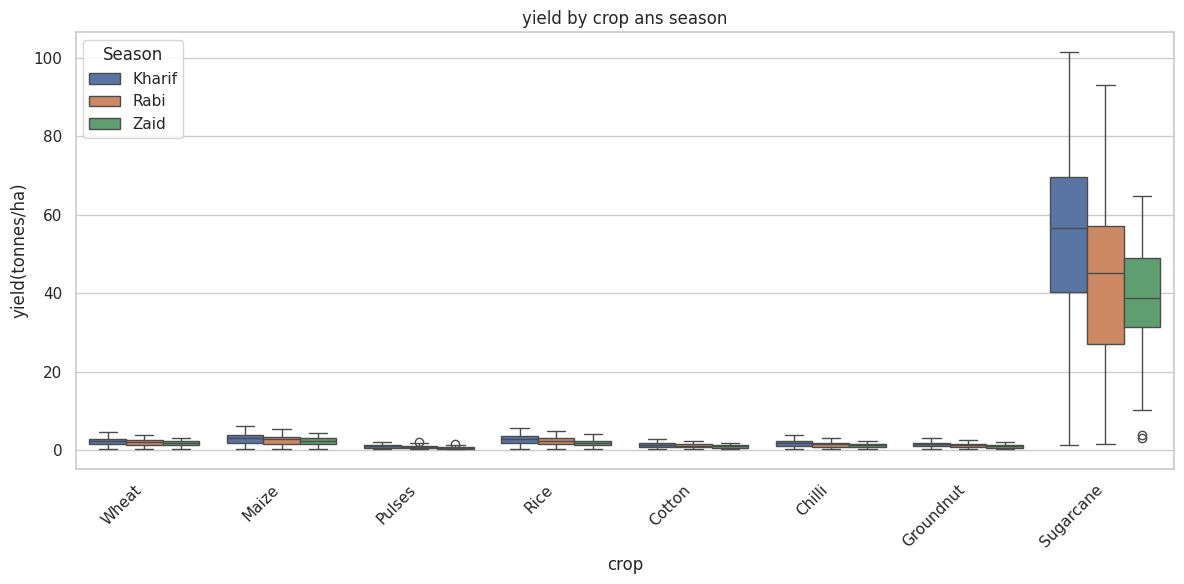

In [137]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="Crop",y="Yield_Tonnes_Ha" , hue="Season")
plt.xticks( rotation=45,ha="right")
plt.title("yield by crop ans season")
plt.xlabel("crop")
plt.ylabel("yield(tonnes/ha)")
plt.tight_layout()
plt.show()


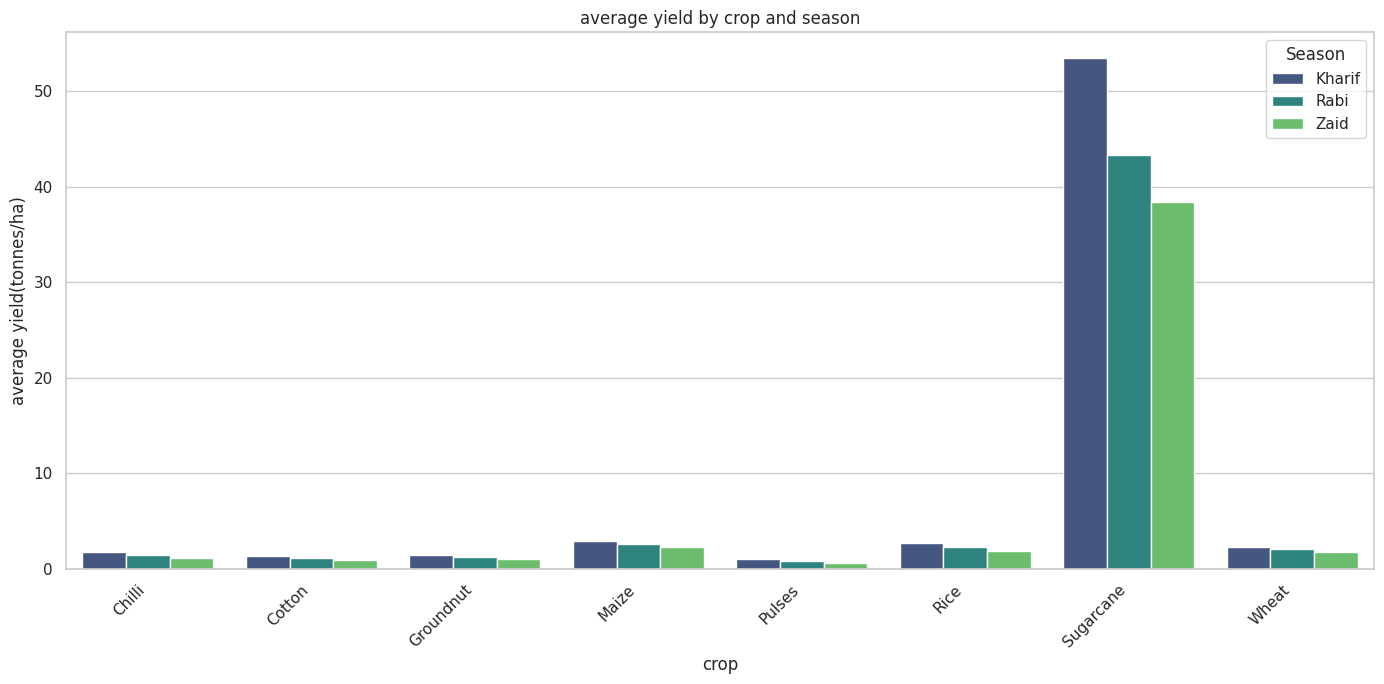

In [138]:
crop_season_summary = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().reset_index(name='Average_Yield')
plt.figure(figsize=(14,7))
sns.barplot(data =crop_season_summary,x="Crop",y="Average_Yield",hue='Season',palette='viridis')
plt.title("average yield by crop and season")
plt.xlabel("crop")
plt.ylabel("average yield(tonnes/ha)")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

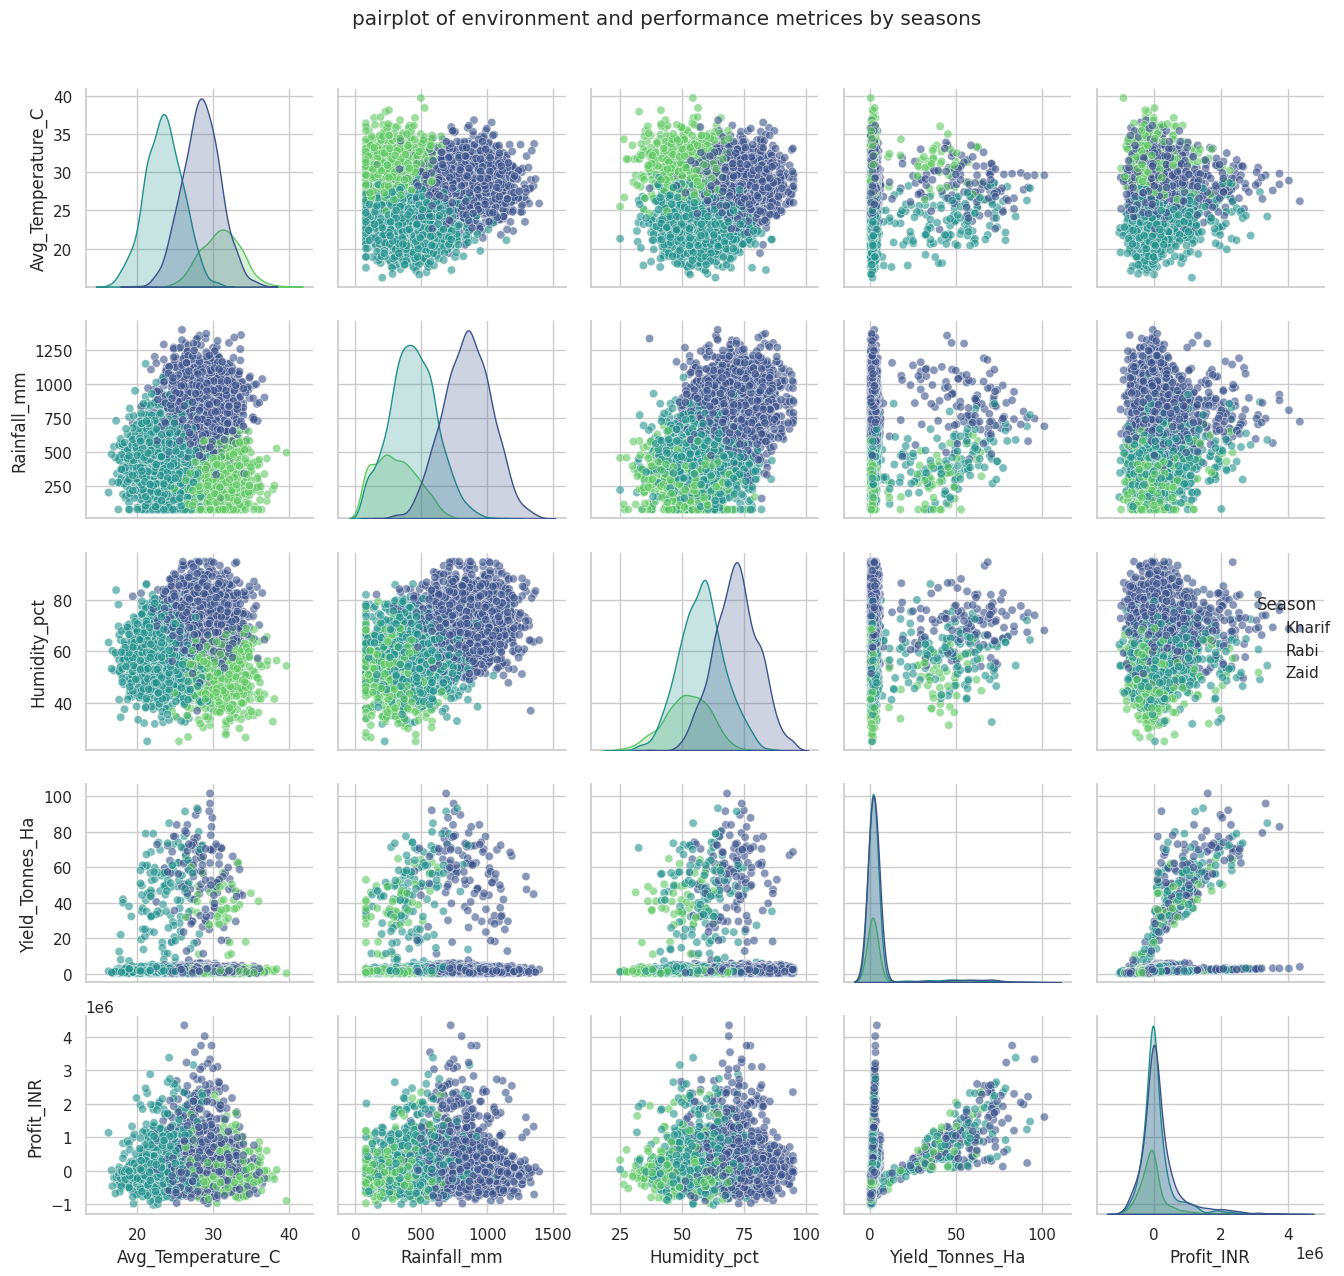

In [139]:
selected_columns=['Avg_Temperature_C','Rainfall_mm','Humidity_pct','Yield_Tonnes_Ha','Profit_INR','Season']
sns.pairplot(df[selected_columns],hue='Season',palette='viridis',plot_kws={'alpha':0.6})
plt.suptitle("pairplot of environment and performance metrices by seasons",y=1.02)
plt.tight_layout()
plt.show()

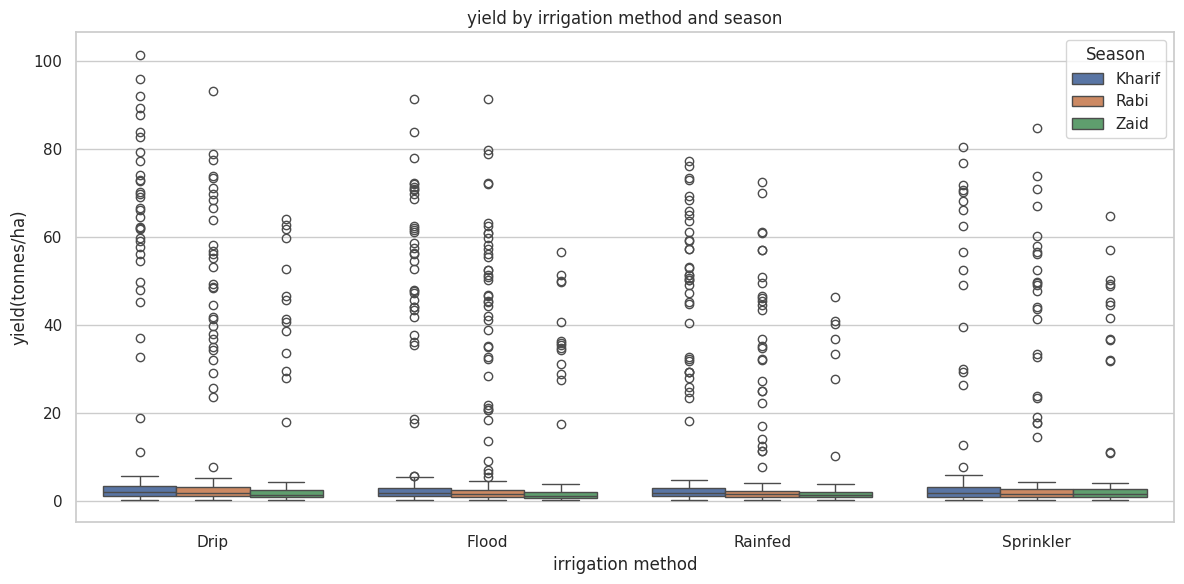

In [140]:
plt.figure(figsize=(12,6))
sns.boxplot(data = df,x="Irrigation_Method",y="Yield_Tonnes_Ha",hue="Season")
plt.title("yield by irrigation method and season")
plt.xlabel("irrigation method")
plt.ylabel("yield(tonnes/ha)")
plt.tight_layout()
plt.show()

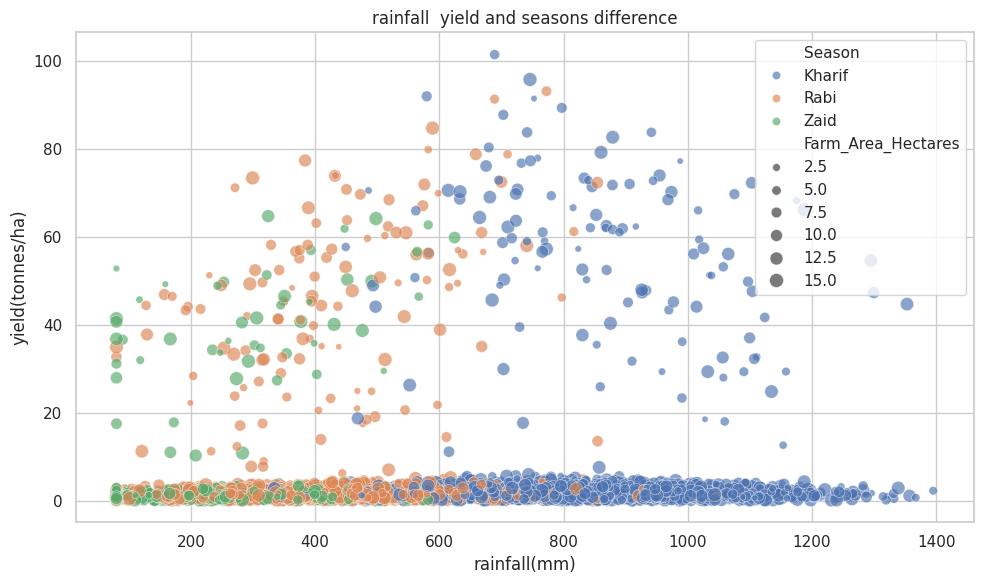

In [141]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    size="Farm_Area_Hectares",
    sizes=(20,100),
    alpha=0.65
)
plt.title("rainfall  yield and seasons difference")
plt.xlabel("rainfall(mm)")
plt.ylabel("yield(tonnes/ha)")
plt.tight_layout()
plt.show()

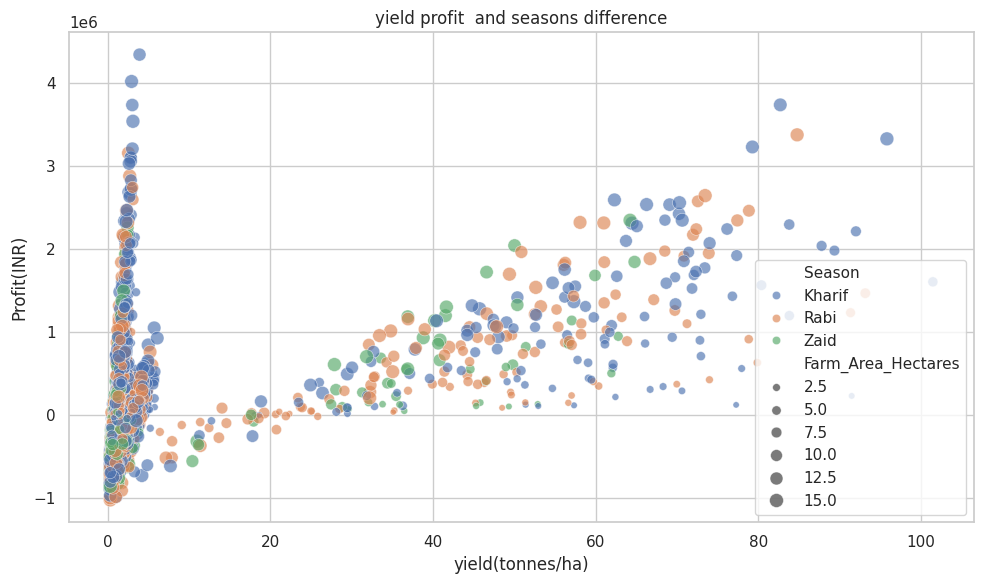

In [142]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    y='Profit_INR',
    x='Yield_Tonnes_Ha',
    hue='Season',
    size="Farm_Area_Hectares",
    sizes=(20,100),
    alpha=0.65
)
plt.title("yield profit  and seasons difference")
plt.ylabel("Profit(INR)")
plt.xlabel("yield(tonnes/ha)")
plt.tight_layout()
plt.show()

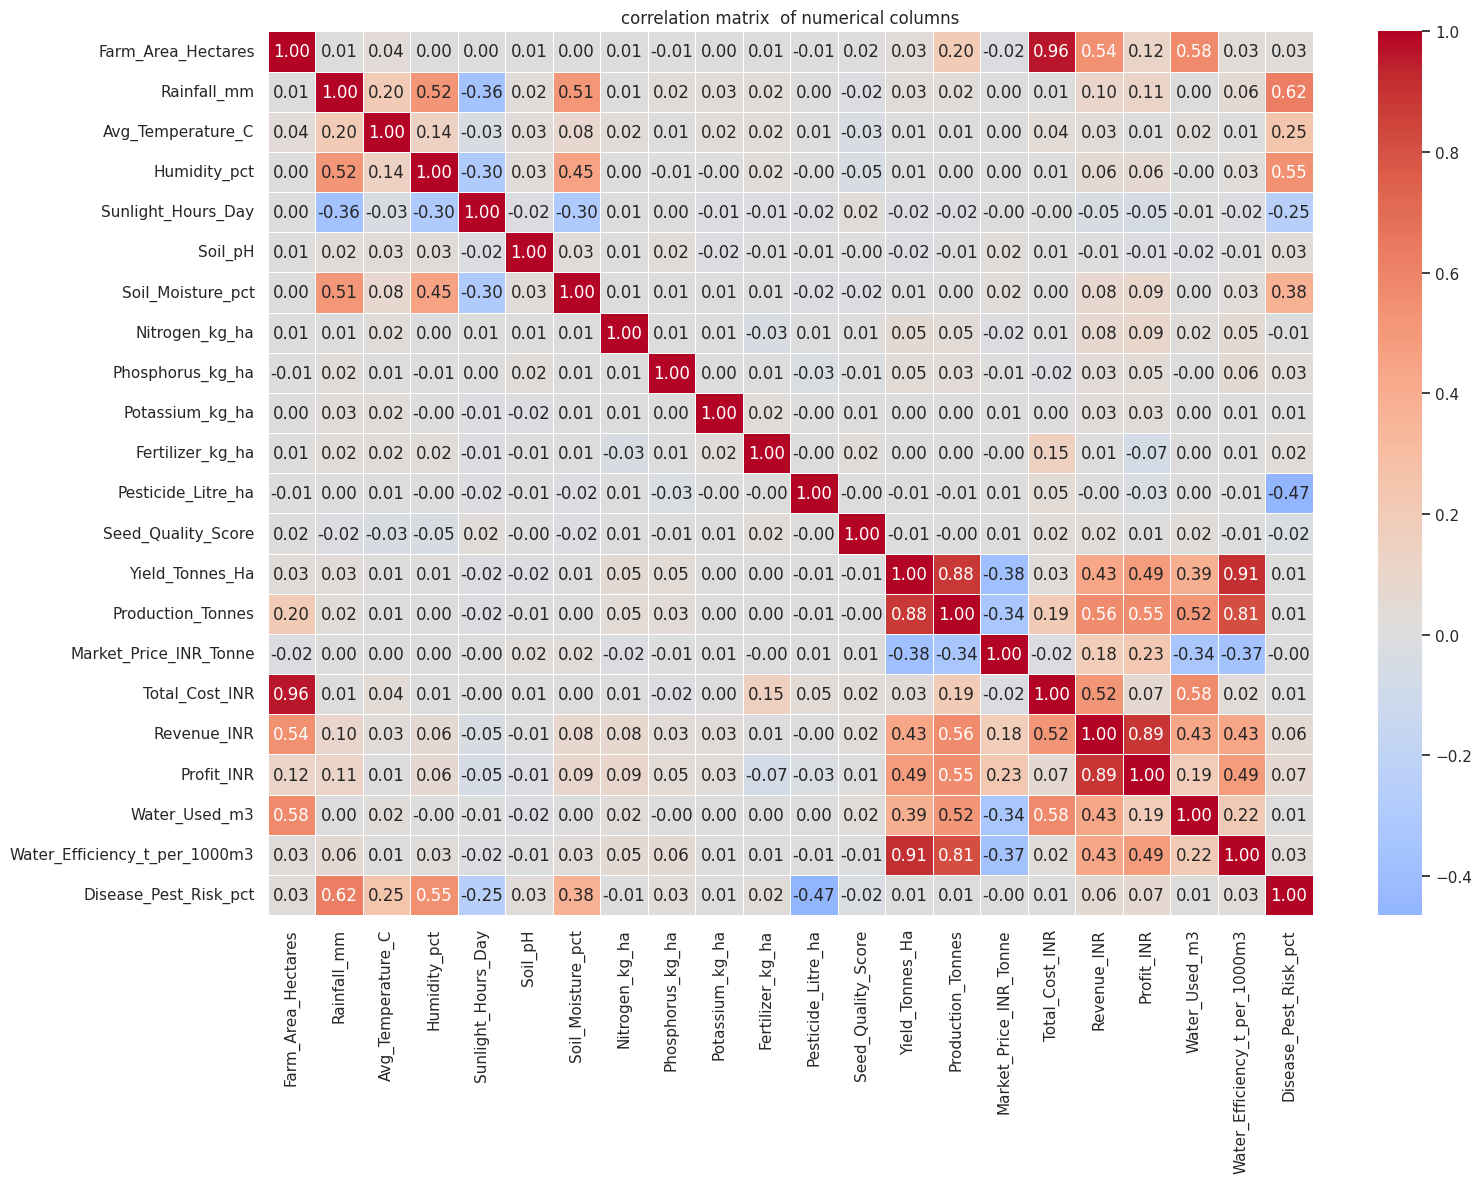

In [143]:
plt.figure(figsize=(16,12))
corr = df[numeric_columns].corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,

)
plt.title("correlation matrix  of numerical columns")
plt.tight_layout()
plt.show()

In [144]:

season_matrics=df.groupby("Season").agg(
    records=("Farm_ID","count"),
    average_yield=("Yield_Tonnes_Ha","mean"),
    Total_Production=("Production_Tonnes","sum"),
    average_profit=("Profit_INR","mean"),
    average_rainfall=("Rainfall_mm","mean"),
    Average_Water_Used=("Water_Used_m3","mean"),

).round(2)
season_matrics

,records,average_yield,Total_Production,average_profit,average_rainfall,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,82387.61,178914.65,849.20,6102.20
Rabi,1627,5.04,67498.88,87689.47,437.62,5846.99
Zaid,594,4.64,23098.35,-24804.82,304.65,6419.89


In [145]:
crop_season_summary = (
    df.groupby(["Crop", "Season"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    )
    .round(2)
    .sort_values(by=["Season", "Average_Yield"], ascending=[True, False])
)
crop_season_summary

,,Average_Yield,Average_Profit,Average_Water_Efficiency
Crop,Season,,,
Sugarcane,Kharif,53.46,1000790.81,36.00
Maize,Kharif,2.97,-39332.67,6.05
Rice,Kharif,2.70,-64903.40,2.17
Wheat,Kharif,2.25,-105871.87,4.76
Chilli,Kharif,1.73,954380.42,3.26
Groundnut,Kharif,1.48,108265.44,3.58
Cotton,Kharif,1.37,216999.55,2.13
Pulses,Kharif,1.04,43338.90,3.35
Sugarcane,Rabi,43.29,731612.86,27.92
